In [3]:
input_files = {
    "r1": "/mnt/sunxh/humancell_dataset/GSM6219611_HepG2-m6A-r1_peaks.narrowPeak",
    "r2": "/mnt/sunxh/humancell_dataset/GSM6219612_HepG2-m6A-r2_peaks.narrowPeak",
}

output_files = {
    "r1": "GSM6219611_gene_MeTPeak.txt",
    "r2": "GSM6219612_gene_MeTPeak.txt",
}

for key in input_files:
    with open(input_files[key]) as infile, open(output_files[key], "w") as outfile:
 
        outfile.write("chrom\tstart\tend\tname\tscore\tstrand\tsignalValue\tpValue\tqValue\tpeak\t.\t.\t.\t.\tfold_change\n")

        for line in infile:
            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue
 
            fold_change = parts[6] 
            fake_cols = parts + ["."] * (14 - len(parts)) + [fold_change]
            outfile.write("\t".join(fake_cols) + "\n")

In [4]:
input_files = {
    "r1": "/mnt/sunxh/humancell_dataset/GSM6219611_HepG2-m6A-r1_peaks.narrowPeak",
    "r2": "/mnt/sunxh/humancell_dataset/GSM6219612_HepG2-m6A-r2_peaks.narrowPeak",
}

output_file = "GSM6219611_9612_merged_gene_MeTPeak.txt"

with open(output_file, "w") as outfile:
 
    outfile.write("chrom\tstart\tend\tname\tscore\tstrand\tsignalValue\tpValue\tqValue\tpeak\t.\t.\t.\t.\tfold_change\n")

    for key in input_files:
        with open(input_files[key]) as infile:
            for line in infile:
                parts = line.strip().split("\t")
                if len(parts) < 9:
                    continue
                fold_change = parts[6] 
                fake_cols = parts + ["."] * (14 - len(parts)) + [fold_change]
                outfile.write("\t".join(fake_cols) + "\n")


In [11]:
import re

m6a_peaks_with_genes = "/mnt/sunxh/datasets/human_call/m6A_peaks_with_genes.txt"
m6A_seq_gene = set()

print("=== Debug m6A-seq annotation ===")
total_lines = 0
matched_gene_name = 0
matched_gene_id = 0

with open(m6a_peaks_with_genes) as f:
    for line in f:
        total_lines += 1
        fields = line.strip().split("\t")
        if len(fields) < 13:
            print(f"Skipped line (too short): {line.strip()}")
            continue
        attr = fields[12]
        match = re.search(r'gene_name "([^"]+)"', attr)
        if match:
            m6A_seq_gene.add(match.group(1))
            matched_gene_name += 1
        else:
            match = re.search(r'gene_id "([^"]+)"', attr)
            if match:
                m6A_seq_gene.add(match.group(1))
                matched_gene_id += 1
            else:
                print(f"Could not match gene_name or gene_id in: {attr}")

print(f"Total lines in m6A file: {total_lines}")
print(f"Matched gene_name: {matched_gene_name}, Matched gene_id (fallback): {matched_gene_id}")
print(f"Unique m6A-seq genes collected: {len(m6A_seq_gene)}")


=== Debug m6A-seq annotation ===
Total lines in m6A file: 600965
Matched gene_name: 600965, Matched gene_id (fallback): 0
Unique m6A-seq genes collected: 11280


In [12]:
predict_gene = set()

print("\n=== Debug TandemMod prediction ===")
total_lines = 0
passing_genes = 0

with open(m6a_predict) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#") or "transcriptome_id" in line:
            continue
        fields = line.split("\t")
        if len(fields) < 12:
            print(f"Skipped (too few fields): {line}")
            continue
        try:
            gene = fields[0].strip()
            mod_count = int(fields[10]) 
            total_count = int(fields[11])
            if total_count > 10 and mod_count / (total_count + 1e-6) > 0.05:
                predict_gene.add(gene)
                passing_genes += 1
        except Exception as e:
            print(f"Error parsing line: {line}\nException: {e}")
        total_lines += 1

print(f"Total lines in prediction file: {total_lines}")
print(f"Genes passing threshold: {passing_genes}")
print(f"Unique predicted genes collected: {len(predict_gene)}")




=== Debug TandemMod prediction ===
Total lines in prediction file: 1821444
Genes passing threshold: 141854
Unique predicted genes collected: 8831


m6A-seq 基因数目: 11280
TandemMod 预测基因数目: 8620
✅ 所有集合信息已保存到: /mnt/sunxh/datasets/human_call/hepg2_m6a_venn_gene_sets.txt


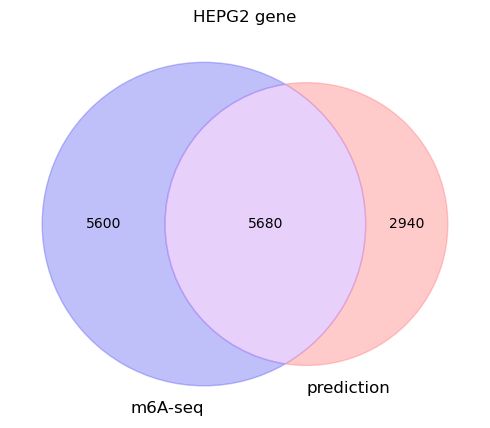

✅ 图像已保存至: /mnt/sunxh/datasets/human_call/figure/hepg2_m6a_venn.pdf


In [21]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import re
import os


base_dir = "/mnt/sunxh/datasets/human_call"
m6a_peaks_with_genes = os.path.join(base_dir, "m6A_peaks_with_genes.txt")
m6a_predict = os.path.join(base_dir, "hepg2.gene1.tsv")
output_figure = os.path.join(base_dir, "figure/hepg2_m6a_venn.pdf")
output_combined = os.path.join(base_dir, "hepg2_m6a_venn_gene_sets.txt")

os.makedirs(os.path.dirname(output_figure), exist_ok=True)


m6A_seq_gene = set()
with open(m6a_peaks_with_genes) as f:
    for line in f:
        fields = line.strip().split("\t")
        if len(fields) < 13:
            continue
        attr = fields[12]
        match = re.search(r'gene_name "([^"]+)"', attr)
        if match:
            m6A_seq_gene.add(match.group(1))
        else:
            match = re.search(r'gene_id "([^"]+)"', attr)
            if match:
                m6A_seq_gene.add(match.group(1))

print(f"m6A-seq 基因数目: {len(m6A_seq_gene)}")


predict_gene = set()
with open(m6a_predict) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#") or "transcriptome_id" in line:
            continue
        fields = line.split("\t")
        if len(fields) < 12:
            continue
        try:
            gene = fields[0].strip()
            mod_count = int(fields[10]) 
            total_count = int(fields[11])
            if total_count > 10 and mod_count / (total_count + 1e-6) > 0.1:
                predict_gene.add(gene)
        except:
            continue

print(f"TandemMod 预测基因数目: {len(predict_gene)}")


overlap = sorted(m6A_seq_gene & predict_gene)
m6a_only = sorted(m6A_seq_gene - predict_gene)
predict_only = sorted(predict_gene - m6A_seq_gene)


max_len = max(len(predict_only), len(m6a_only), len(overlap))

with open(output_combined, "w") as f:
    f.write("TandemMod_only\tm6A-seq_only\toverlap\n")
    for i in range(max_len):
        col1 = predict_only[i] if i < len(predict_only) else ""
        col2 = m6a_only[i] if i < len(m6a_only) else ""
        col3 = overlap[i] if i < len(overlap) else ""
        f.write(f"{col1}\t{col2}\t{col3}\n")


print(f"✅ 所有集合信息已保存到: {output_combined}")


plt.figure(figsize=(5, 5))
venn = venn2([m6A_seq_gene, predict_gene],
             set_labels=("m6A-seq", "prediction"))


if venn.get_patch_by_id('10'): venn.get_patch_by_id('10').set_color('#5F5FF3') 
if venn.get_patch_by_id('01'): venn.get_patch_by_id('01').set_color('#FF7C7C') 
if venn.get_patch_by_id('11'): venn.get_patch_by_id('11').set_color('#C48EF5') 

plt.title("HEPG2 gene")
plt.tight_layout()
plt.savefig(output_figure)
plt.show()
print(f"至: {output_figure}")
